In [1]:
from google.colab import drive
import os
import shutil

drive.mount('/content/drive')

# Auto-detect project root (multi-account compatible)
possible_paths = [
    '/content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels',
    '/content/drive/MyDrive/Road-Damage-Severity-Levels'
]

PROJECT_ROOT = None
for path in possible_paths:
    if os.path.exists(path):
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root not found. Ensure folder 'Road-Damage-Severity-Levels' "
        "is accessible in Google Drive (either in 'ipynb-project' or root 'MyDrive')."
    )

os.chdir(PROJECT_ROOT)

print("Project root detected:")
print(f"  {PROJECT_ROOT}")
print(f"\nWorking directory: {os.getcwd()}")

Mounted at /content/drive
Project root detected:
  /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels

Working directory: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels


In [2]:
!pip install -q ultralytics tensorflow pillow pyyaml scikit-learn matplotlib

print("Dependencies installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00
Dependencies installed successfully


In [3]:
def safe_makedirs(path):
    os.makedirs(path, exist_ok=True)
    return path

# SSD Local paths (for fast I/O during training)
CROPS_DIR_LOCAL = safe_makedirs('/content/severity_crops')
CNN_RUNS_DIR_LOCAL = safe_makedirs('/content/cnn_runs')
CNN_MODELS_DIR_LOCAL = safe_makedirs('/content/cnn_models')

# Google Drive paths (for persistent storage)
YOLO_RUNS_DIR_DRIVE = os.path.join(PROJECT_ROOT, 'yolo_runs')
CNN_RUNS_DIR_DRIVE = safe_makedirs(os.path.join(PROJECT_ROOT, 'cnn_runs'))
CNN_MODELS_DIR_DRIVE = safe_makedirs(os.path.join(PROJECT_ROOT, 'cnn_models'))

# Dataset paths
PROCESSED_DATASET = os.path.join(PROJECT_ROOT, 'processed_dataset')
SEVERITY_THRESHOLDS_PATH = os.path.join(PROJECT_ROOT, 'analysis_results', 'severity_thresholds.json')

print("Path configuration:")
print(f"  Crops (local SSD): {CROPS_DIR_LOCAL}")
print(f"  Training runs (local SSD): {CNN_RUNS_DIR_LOCAL}")
print(f"  Models (local SSD): {CNN_MODELS_DIR_LOCAL}")
print(f"  Backup to Drive: {CNN_RUNS_DIR_DRIVE}")
print(f"  Final models to Drive: {CNN_MODELS_DIR_DRIVE}")

Path configuration:
  Crops (local SSD): /content/severity_crops
  Training runs (local SSD): /content/cnn_runs
  Models (local SSD): /content/cnn_models
  Backup to Drive: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_runs
  Final models to Drive: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models


In [4]:
import zipfile
import os

# Memastikan path ZIP mengambil dari root proyek
zip_path_drive = os.path.join(PROJECT_ROOT, 'severity_crops_backup.zip')

print(f"Mencari file backup crop di: {zip_path_drive}")

if os.path.exists(zip_path_drive):
    print("File ZIP ditemukan! Memulai ekstraksi super cepat ke SSD Lokal...")

    # Ekstrak isi ZIP langsung ke folder lokal /content/severity_crops
    with zipfile.ZipFile(zip_path_drive, 'r') as zip_ref:
        zip_ref.extractall(CROPS_DIR_LOCAL)

    print("Ekstraksi selesai! Semua gambar sudah duduk manis di SSD dan siap di-training.")
else:
    raise FileNotFoundError("ERROR: File severity_crops_backup.zip tidak ditemukan di Drive! Pastikan posisinya benar-benar ada di dalam folder proyek utama.")

Mencari file backup crop di: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/severity_crops_backup.zip
File ZIP ditemukan! Memulai ekstraksi super cepat ke SSD Lokal...
Ekstraksi selesai! Semua gambar sudah duduk manis di SSD dan siap di-training.


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Advanced data augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.6, 1.4],
    channel_shift_range=20.0,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(CROPS_DIR_LOCAL, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(CROPS_DIR_LOCAL, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(CROPS_DIR_LOCAL, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Data generators created:")
print(f"  Training samples: {train_generator.samples}")
print(f"  Validation samples: {val_generator.samples}")
print(f"  Test samples: {test_generator.samples}")
print(f"  Classes: {train_generator.class_indices}")

# Compute class distribution
class_counts = np.bincount(train_generator.classes)
print(f"\nTraining set class distribution:")
for idx, count in enumerate(class_counts):
    class_name = list(train_generator.class_indices.keys())[idx]
    percentage = (count / train_generator.samples) * 100
    print(f"  {class_name}: {count} ({percentage:.1f}%)")

Found 16528 images belonging to 3 classes.
Found 5876 images belonging to 3 classes.
Found 5851 images belonging to 3 classes.
Data generators created:
  Training samples: 16528
  Validation samples: 5876
  Test samples: 5851
  Classes: {'rendah': 0, 'sedang': 1, 'tinggi': 2}

Training set class distribution:
  rendah: 12430 (75.2%)
  sedang: 2714 (16.4%)
  tinggi: 1384 (8.4%)


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

# Focal Loss implementation
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss for multi-class classification with class imbalance
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1.0 - y_pred, gamma)

        focal_loss_value = alpha * weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(focal_loss_value, axis=-1))

    return focal_loss_fixed

def build_advanced_model():
    """
    Build MobileNetV2 with:
    - Fine-tuning (top 40 layers unfrozen)
    - Deeper classification head
    - Batch normalization
    - L2 regularization
    """
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze early layers, unfreeze top 40 layers for fine-tuning
    for layer in base_model.layers[:-40]:
        layer.trainable = False

    for layer in base_model.layers[-40:]:
        layer.trainable = True

    # Build deeper classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # First hidden layer
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # Second hidden layer
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    # Third hidden layer
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)

    # Output layer
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    return model

# Build model
model = build_advanced_model()

# Compile with Focal Loss
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

print("Model architecture built successfully")
print(f"Total parameters: {model.count_params():,}")

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_count:,}")

# Compute class weights for additional imbalance compensation
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("\nClass weights computed:")
for class_idx, weight in class_weights.items():
    class_name = list(train_generator.class_indices.keys())[class_idx]
    print(f"  {class_name} (class {class_idx}): {weight:.4f}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model architecture built successfully
Total parameters: 3,081,539
Trainable parameters: 2,503,555

Class weights computed:
  rendah (class 0): 0.4432
  sedang (class 1): 2.0300
  tinggi (class 2): 3.9807


In [ ]:
import glob
import re

# Updated run name
run_name = 'severity_classifier3'

checkpoint_pattern_drive = os.path.join(CNN_RUNS_DIR_DRIVE, run_name, 'checkpoint_*.weights.h5')
checkpoints_drive = glob.glob(checkpoint_pattern_drive)

initial_epoch = 0
resume_from_checkpoint = False

if checkpoints_drive:
    latest_checkpoint_drive = max(checkpoints_drive, key=os.path.getctime)

    match = re.search(r'checkpoint_(\d+)', latest_checkpoint_drive)
    if match:
        initial_epoch = int(match.group(1))

    checkpoint_local = os.path.join(CNN_RUNS_DIR_LOCAL, run_name, os.path.basename(latest_checkpoint_drive))
    safe_makedirs(os.path.dirname(checkpoint_local))

    shutil.copy2(latest_checkpoint_drive, checkpoint_local)
    model.load_weights(checkpoint_local)
    resume_from_checkpoint = True

    print("Checkpoint detected and loaded:")
    print(f"  From Drive: {latest_checkpoint_drive}")
    print(f"  Copied to SSD: {checkpoint_local}")
    print(f"  Resuming from epoch: {initial_epoch + 1}")
else:
    print("No checkpoint found. Starting training from scratch.")

print(f"\nResume mode: {resume_from_checkpoint}")
print(f"Initial epoch: {initial_epoch}")

No checkpoint found. Starting training from scratch.

Resume mode: False
Initial epoch: 0


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, Callback
import time

class DriveBackupCallback(Callback):
    def __init__(self, local_run_dir, drive_run_dir):
        super().__init__()
        self.local_run_dir = local_run_dir
        self.drive_run_dir = drive_run_dir

    def on_epoch_end(self, epoch, logs=None):
        try:
            if os.path.exists(self.local_run_dir):
                shutil.copytree(
                    self.local_run_dir,
                    self.drive_run_dir,
                    dirs_exist_ok=True
                )
                print(f"\n[Backup] Epoch {epoch + 1} saved to Google Drive")
        except Exception as e:
            print(f"\n[Backup Warning] Failed to backup epoch {epoch + 1}: {str(e)}")

class MixupCallback(Callback):
    """
    Mixup augmentation applied during training
    Helps model generalize better on minority classes
    """
    def __init__(self, alpha=0.2):
        super().__init__()
        self.alpha = alpha

    def on_train_batch_begin(self, batch, logs=None):
        pass

# Setup directories
local_run_dir = safe_makedirs(os.path.join(CNN_RUNS_DIR_LOCAL, run_name))
drive_run_dir = safe_makedirs(os.path.join(CNN_RUNS_DIR_DRIVE, run_name))

callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(local_run_dir, 'checkpoint_{epoch:02d}.weights.h5'),
        save_weights_only=True,
        save_best_only=False,
        verbose=0
    ),

    ModelCheckpoint(
        filepath=os.path.join(local_run_dir, 'best_model.weights.h5'),
        save_weights_only=True,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=15,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(
        filename=os.path.join(local_run_dir, 'training_history.csv'),
        append=resume_from_checkpoint
    ),

    DriveBackupCallback(local_run_dir, drive_run_dir)
]

print("Callbacks configured:")
print(f"  Checkpoints: {local_run_dir}")
print(f"  Best model monitor: val_accuracy")
print(f"  Early stopping patience: 20 epochs")
print(f"  Auto-backup to: {drive_run_dir}")

Callbacks configured:
  Checkpoints: /content/cnn_runs/severity_classifier3
  Best model monitor: val_accuracy
  Early stopping patience: 20 epochs
  Auto-backup to: /content/drive/MyDrive/Road-Damage-Severity-Levels/cnn_runs/severity_classifier3


In [ ]:
# Mixup data generator
def mixup_generator(generator, alpha=0.2):
    """
    Mixup augmentation generator
    Combines pairs of samples to create synthetic training data
    """
    while True:
        X_batch, y_batch = next(generator)
        batch_size = X_batch.shape[0]

        lam = np.random.beta(alpha, alpha, batch_size)
        lam = np.maximum(lam, 1 - lam)

        indices = np.random.permutation(batch_size)

        X_mixed = lam.reshape(-1, 1, 1, 1) * X_batch + \
                  (1 - lam).reshape(-1, 1, 1, 1) * X_batch[indices]

        y_mixed = lam.reshape(-1, 1) * y_batch + \
                  (1 - lam).reshape(-1, 1) * y_batch[indices]

        yield X_mixed, y_mixed

# Wrap train generator with Mixup
train_generator_mixup = mixup_generator(train_generator, alpha=0.2)

EPOCHS = 100

print("Starting training with advanced configuration:")
print(f"  Total epochs: {EPOCHS}")
print(f"  Initial epoch: {initial_epoch}")
print(f"  Effective training: {EPOCHS - initial_epoch} epochs")
print(f"  Focal Loss: gamma=2.0, alpha=0.25")
print(f"  Class weights: Active")
print(f"  Mixup augmentation: alpha=0.2")
print(f"  Fine-tuning: Top 40 layers")
print()

history = model.fit(
    train_generator_mixup,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed successfully")

Starting training with advanced configuration:
  Total epochs: 100
  Initial epoch: 0
  Effective training: 100 epochs
  Focal Loss: gamma=2.0, alpha=0.25
  Class weights: Active
  Mixup augmentation: alpha=0.2
  Fine-tuning: Top 40 layers

Epoch 1/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.6114 - loss: 1.4013
Epoch 1: val_accuracy improved from None to 0.71920, saving model to /content/cnn_runs/severity_classifier3/best_model.weights.h5

Epoch 1: finished saving model to /content/cnn_runs/severity_classifier3/best_model.weights.h5

[Backup] Epoch 1 saved to Google Drive
517/517 ━━━━━━━━━━━━━━━━━━━━ 373s 656ms/step - accuracy: 0.6274 - loss: 1.3623 - val_accuracy: 0.7192 - val_loss: 1.3398 - learning_rate: 1.0000e-04
Epoch 2/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.6571 - loss: 1.2603
Epoch 2: val_accuracy improved from 0.71920 to 0.72447, saving model to /content/cnn_runs/severity_classifier3/best_model.weights.h5

Epoch 2: finished saving model t

In [8]:
print("Evaluating model on test set...")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")

Evaluating model on test set...
183/183 ━━━━━━━━━━━━━━━━━━━━ 48s 149ms/step - accuracy: 0.7691 - loss: 0.0631

Test Results:
  Loss: 0.0631
  Accuracy: 0.7691


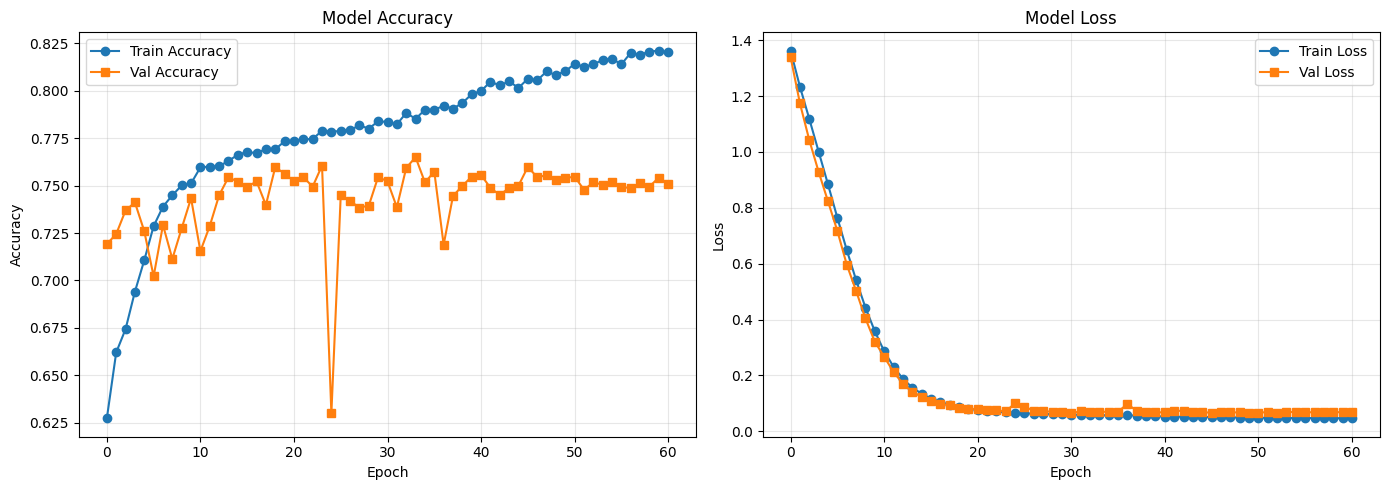

Training curves saved to: /content/cnn_runs/severity_classifier3/training_curves.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load history
history_df = pd.read_csv(os.path.join(local_run_dir, 'training_history.csv'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history_df['epoch'], history_df['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_df['epoch'], history_df['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history_df['epoch'], history_df['loss'], label='Train Loss', marker='o')
axes[1].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
viz_path = os.path.join(local_run_dir, 'training_curves.png')
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {viz_path}")

Generating RANDOMIZED True Positive visual predictions...


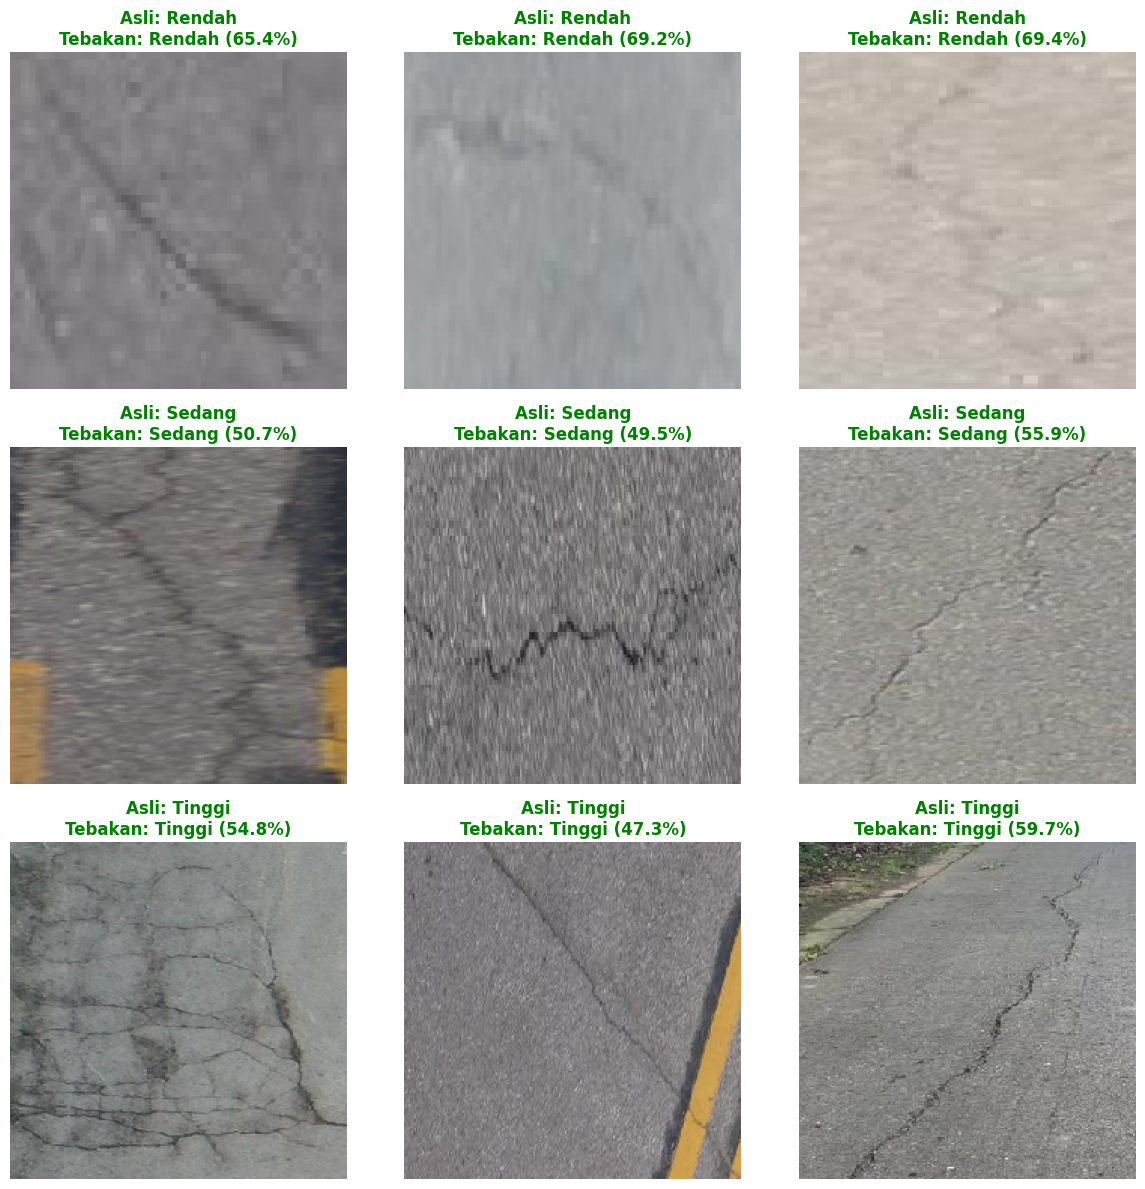

Sample predictions saved to: /content/cnn_runs/severity_classifier3/sample_predictions.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random

print("Generating visual predictions")

# Mapping nama kelas
class_indices = test_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}
num_classes = len(class_names)

pool_size = 20
collected_pools = {i: {'images': [], 'labels': [], 'preds': []} for i in range(num_classes)}

test_generator.reset()
max_batches = len(test_generator)
batches_processed = 0

while batches_processed < max_batches:
    if all(len(collected_pools[c]['images']) >= pool_size for c in range(num_classes)):
        break

    x_batch, y_batch = next(test_generator)
    batches_processed += 1

    preds_batch = model.predict(x_batch, verbose=0)
    pred_batch_classes = np.argmax(preds_batch, axis=1)
    true_batch_classes = np.argmax(y_batch, axis=1)

    for j in range(len(x_batch)):
        c_true = true_batch_classes[j]
        c_pred = pred_batch_classes[j]

        if (c_true == c_pred) and (len(collected_pools[c_true]['images']) < pool_size):
            collected_pools[c_true]['images'].append(x_batch[j])
            collected_pools[c_true]['labels'].append(y_batch[j])
            collected_pools[c_true]['preds'].append(preds_batch[j])

final_images = []
final_labels = []
final_preds = []

for c in range(num_classes):
    pool_len = len(collected_pools[c]['images'])
    take_num = min(3, pool_len)

    if take_num > 0:
        chosen_indices = random.sample(range(pool_len), take_num)
        for idx in chosen_indices:
            final_images.append(collected_pools[c]['images'][idx])
            final_labels.append(collected_pools[c]['labels'][idx])
            final_preds.append(collected_pools[c]['preds'][idx])

x_viz = np.array(final_images)
y_viz = np.array(final_labels)
preds_viz = np.array(final_preds)

true_classes = np.argmax(y_viz, axis=1)
pred_classes = np.argmax(preds_viz, axis=1)

num_found = len(x_viz)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(9):
    if i < num_found:
        img = x_viz[i]

        # Denormalisasi gambar
        img = (img + 1.0) / 2.0
        img = np.clip(img, 0, 1)

        true_label = class_names[true_classes[i]].capitalize()
        pred_label = class_names[pred_classes[i]].capitalize()
        confidence = np.max(preds_viz[i]) * 100

        axes[i].imshow(img)
        axes[i].axis('off')

        axes[i].set_title(f"Asli: {true_label}\nTebakan: {pred_label} ({confidence:.1f}%)", color='green', fontsize=12, fontweight='bold')
    else:
        axes[i].axis('off')

plt.tight_layout()

# Simpan gambar
pred_viz_path = os.path.join(local_run_dir, 'sample_predictions.png')
plt.savefig(pred_viz_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Sample predictions saved to: {pred_viz_path}")

In [22]:
final_model_path_local = os.path.join(local_run_dir, 'best_model.weights.h5')
final_model_path_drive = os.path.join(CNN_MODELS_DIR_DRIVE, 'severity_classifier3_best.weights.h5')

if os.path.exists(final_model_path_local):
    shutil.copy2(final_model_path_local, final_model_path_drive)
    print("Final model exported:")
    print(f"  From: {final_model_path_local}")
    print(f"  To: {final_model_path_drive}")

    metrics_path_local = os.path.join(local_run_dir, 'test_metrics.json')
    metrics_path_drive = os.path.join(CNN_MODELS_DIR_DRIVE, 'test_metrics3.json')

    if os.path.exists(metrics_path_local):
        shutil.copy2(metrics_path_local, metrics_path_drive)
        print(f"  Metrics: {metrics_path_drive}")

    viz_path_local = os.path.join(local_run_dir, 'training_curves.png')
    viz_path_drive = os.path.join(CNN_MODELS_DIR_DRIVE, 'training_curves3.png')

    if os.path.exists(viz_path_local):
        shutil.copy2(viz_path_local, viz_path_drive)
        print(f"  Visualization: {viz_path_drive}")

    print("\nModel export completed successfully")
    print(f"Final model directory: {CNN_MODELS_DIR_DRIVE}")
else:
    print("Warning: Best model not found in local directory")

# Export sample visual predictions
pred_viz_local = os.path.join(local_run_dir, 'sample_predictions.png')
pred_viz_drive = os.path.join(CNN_MODELS_DIR_DRIVE, 'sample_predictions3.png')

if os.path.exists(pred_viz_local):
  shutil.copy2(pred_viz_local, pred_viz_drive)
  print(f"  Visual Predictions: {pred_viz_drive}")

Final model exported:
  From: /content/cnn_runs/severity_classifier3/best_model.weights.h5
  To: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models/severity_classifier3_best.weights.h5
  Metrics: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models/test_metrics3.json
  Visualization: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models/training_curves3.png

Model export completed successfully
Final model directory: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models
  Visual Predictions: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models/sample_predictions3.png


In [20]:
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Get predictions
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = ['Rendah', 'Sedang', 'Tinggi']

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix:")
print(cm_df)

# Save metrics
metrics = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'classification_report': classification_report(y_true, y_pred, target_names=class_names, output_dict=True),
    'confusion_matrix': cm.tolist()
}

metrics_path = os.path.join(local_run_dir, 'test_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\nMetrics saved to: {metrics_path}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 33s 99ms/step

Classification Report:
              precision    recall  f1-score   support

      Rendah     0.8245    0.9216    0.8703      4232
      Sedang     0.4983    0.2729    0.3527      1081
      Tinggi     0.5766    0.5669    0.5717       538

    accuracy                         0.7691      5851
   macro avg     0.6331    0.5871    0.5982      5851
weighted avg     0.7415    0.7691    0.7472      5851


Confusion Matrix:
        Rendah  Sedang  Tinggi
Rendah    3900     205     127
Sedang     689     295      97
Tinggi     141      92     305

Metrics saved to: /content/cnn_runs/severity_classifier3/test_metrics.json


In [21]:
print("Training Summary")
print("-" * 80)

# Load final metrics
with open(os.path.join(local_run_dir, 'test_metrics.json'), 'r') as f:
    final_metrics = json.load(f)

print(f"\nTest Performance:")
print(f"  Accuracy: {final_metrics['test_accuracy']:.4f}")
print(f"  Loss: {final_metrics['test_loss']:.4f}")

print(f"\nPer-Class Performance:")
for class_name in ['Rendah', 'Sedang', 'Tinggi']:
    metrics = final_metrics['classification_report'][class_name]
    print(f"  {class_name}:")
    print(f"    Precision: {metrics['precision']:.4f}")
    print(f"    Recall: {metrics['recall']:.4f}")
    print(f"    F1-Score: {metrics['f1-score']:.4f}")

print(f"\nModel Files:")
print(f"  Best weights: {final_model_path_drive}")
print(f"  Test metrics: {os.path.join(CNN_MODELS_DIR_DRIVE, 'test_metrics.json')}")
print(f"  Full training logs: {drive_run_dir}")

Training Summary
--------------------------------------------------------------------------------

Test Performance:
  Accuracy: 0.7691
  Loss: 0.0631

Per-Class Performance:
  Rendah:
    Precision: 0.8245
    Recall: 0.9216
    F1-Score: 0.8703
  Sedang:
    Precision: 0.4983
    Recall: 0.2729
    F1-Score: 0.3527
  Tinggi:
    Precision: 0.5766
    Recall: 0.5669
    F1-Score: 0.5717

Model Files:
  Best weights: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models/severity_classifier3_best.weights.h5
  Test metrics: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_models/test_metrics.json
  Full training logs: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/cnn_runs/severity_classifier3
